# Arabic Handwritten Word Recognition — v3
**Run cells top to bottom. Do not skip any cell.**

### Key improvements over v2
- **Multi-class YOLO (28 classes)** — detector predicts both box AND letter class simultaneously, eliminating the biggest source of error
- **Larger CNN input: 96×96** — better dot fidelity (dots on beh/teh/theh/noon are critical)
- **Expanded crop padding (12%)** — reduces partial-letter crops
- **Dot-preservation step** — tiny connected components (dots) are detected and re-attached to the nearest base glyph crop before classification
- **CNN fine-tuned on real detector crops** — bridges train/inference domain mismatch
- **Character-level accuracy diagnostics** — crop quality metrics (ink area, aspect, dot count)
- **Sequence post-correction** — top-k beam search over per-position predictions
- **Mixed-precision training** — 1.5-2× faster on GPU with no accuracy loss
- All my_chars folders preserved (none skipped)


## Cell 1 — Install dependencies

In [1]:
import sys, os
print('Installing into:', sys.executable)

# Install core libs first
%pip install --upgrade pip -q
%pip install "tensorflow==2.18.0" "keras==3.8.0" ultralytics matplotlib scikit-learn tqdm pyyaml -q
%pip install --force-reinstall "torch==2.5.1" "torchvision==0.20.1" "torchaudio==2.5.1" -q
%pip install --force-reinstall "opencv-python-headless==4.10.0.84" -q

# Force NumPy LAST so it is not upgraded back by later installs
%pip install --force-reinstall "numpy==1.26.4" -q

print('Dependency install complete. Restart kernel, then run Cells 2, 8, 9, 10.')

Installing into: c:\Users\hagar\AppData\Local\Programs\Python\Python311\python.exe
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
label-studio 1.23.0 requires requests<2.33.0,>=2.32.3, but you have requests 2.33.1 which is incompatible.
label-studio-sdk 2.0.18 requires opencv-python-headless<5.0.0,>=4.12.0, but you have opencv-python-headless 4.10.0.84 which is incompatible.
tensorflow-intel 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 2.4.4 which is incompatible.


Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
label-studio 1.23.0 requires requests<2.33.0,>=2.32.3, but you have requests 2.33.1 which is incompatible.
label-studio-sdk 2.0.18 requires opencv-python-headless<5.0.0,>=4.12.0, but you have opencv-python-headless 4.10.0.84 which is incompatible.
tensorflow-intel 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 2.4.4 which is incompatible.


Note: you may need to restart the kernel to use updated packages.
Dependency install complete. Restart kernel, then run Cells 2, 8, 9, 10.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
label-studio 1.23.0 requires numpy<3.0.0,>=2.2.6, but you have numpy 1.26.4 which is incompatible.
label-studio 1.23.0 requires requests<2.33.0,>=2.32.3, but you have requests 2.33.1 which is incompatible.
label-studio-sdk 2.0.18 requires numpy<3.0.0,>=2.2, but you have numpy 1.26.4 which is incompatible.
label-studio-sdk 2.0.18 requires opencv-python-headless<5.0.0,>=4.12.0, but you have opencv-python-headless 4.10.0.84 which is incompatible.


## Cell 2 — Imports, Paths & GPU Setup

In [1]:
import numpy as np
import torch

print('NumPy:', np.__version__)
print('Torch:', torch.__version__)
_ = torch.from_numpy(np.zeros((2, 2), dtype=np.float32))
print('torch.from_numpy preflight: OK')

NumPy: 1.26.4
Torch: 2.5.1+cpu
torch.from_numpy preflight: OK


In [2]:
import numpy as np
import cv2
import os
import re
import random
import shutil
import yaml
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter, defaultdict
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import (
    Conv2D, MaxPool2D, Flatten, Dense, Dropout, BatchNormalization,
    SpatialDropout2D, GlobalAveragePooling2D, Input, Add, Activation
)
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import regularizers, mixed_precision
from ultralytics import YOLO

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

# ─── GPU detection & mixed precision ─────────────────────────────────────────
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU(s) found: {[g.name for g in gpus]}")
    for g in gpus:
        tf.config.experimental.set_memory_growth(g, True)
    # Mixed precision: float16 compute, float32 weights → ~1.5-2× faster
    mixed_precision.set_global_policy('mixed_float16')
    print("Mixed precision enabled (float16).")
    DEVICE = '0'
else:
    print("No GPU found — using CPU (training will be slow)")
    DEVICE = 'cpu'

# ─── Paths ─────────────────────────────────────────────────────────────────
def detect_root() -> Path:
    candidates = [
        Path.cwd(),
        Path('/mnt/f/newbach/Arabic-Handwritten-Characters-Recognition-using-CNN'),
        Path('F:/newbach/Arabic-Handwritten-Characters-Recognition-using-CNN'),
    ]
    for p in candidates:
        if (p / 'isolated_alphabets_per_alphabet').exists() and (p / 'my_dataset').exists():
            return p
    cur = Path.cwd().resolve()
    for parent in [cur] + list(cur.parents):
        if (parent / 'ArabicWordRecognition_v3.ipynb').exists() and (parent / 'isolated_alphabets_per_alphabet').exists():
            return parent
        if (parent / 'isolated_alphabets_per_alphabet').exists() and (parent / 'my_dataset').exists():
            return parent
    return Path.cwd().resolve()

ROOT        = detect_root()
AHAWP_DIR   = ROOT / 'isolated_alphabets_per_alphabet'
MY_CHARS    = ROOT / 'my_chars'
MY_DATASET  = ROOT / 'my_dataset'
MNIST_TRAIN = ROOT / 'arabic-chars-mnist' / 'train'
MNIST_TEST  = ROOT / 'arabic-chars-mnist' / 'test'

# ─── Image size raised to 96×96 for better dot fidelity ──────────────────────
IMG_SIZE = 96

# ─── Arabic letter registry ────────────────────────────────────────────────
ARABIC_28 = [
    'ain','alef','beh','dad','dal','feh','ghain','hah','heh','jeem',
    'kaf','khah','lam','meem','noon','qaf','reh','sad','seen','sheen',
    'tah','teh','thal','theh','waw','yeh','zah','zain'
]
# Map YOLO class index → letter name (sorted = alphabetical = consistent)
CLASS_IDX_TO_NAME = {i: name for i, name in enumerate(sorted(ARABIC_28))}
CLASS_NAME_TO_IDX = {name: i for i, name in CLASS_IDX_TO_NAME.items()}
NUM_LETTER_CLASSES = len(ARABIC_28)  # 28

AHAWP_TO_STD = {
    'ain':'ain','alif':'alef','beh':'beh','dal':'dal','feh':'feh',
    'heh':'heh','jeem':'jeem','kaf':'kaf','lam':'lam','meem':'meem',
    'noon':'noon','qaf':'qaf','raa':'reh','sad':'sad','seen':'seen',
    'tah':'tah','waw':'waw','yaa':'yeh',
    'dad':'dad','ghain':'ghain','hah':'hah','khah':'khah',
    'sheen':'sheen','teh':'teh','thal':'thal','theh':'theh',
    'zah':'zah','zain':'zain',
}

# All my_chars subfolders preserved — none are skipped
MYCHARS_TO_STD = {
    'ain_beginning':'ain','ain_end':'ain','ain_middle':'ain','ain_isolated':'ain',
    'alif_end':'alef','alif_isolated':'alef','alif_hamza':'alef',
    'beh_beginning':'beh','beh_end':'beh','beh_middle':'beh','beh_isolated':'beh',
    'dad_beginning':'dad','dad_end':'dad','dad_middle':'dad','dad_isolated':'dad',
    'dal_end':'dal','dal_isolated':'dal',
    'feh_beginning':'feh','feh_end':'feh','feh_middle':'feh','feh_isolated':'feh',
    'ghain_beginning':'ghain','ghain_end':'ghain','ghain_middle':'ghain','ghain_isolated':'ghain',
    'hah_beginning':'hah','hah_end':'hah','hah_middle':'hah','hah_isolated':'hah',
    'heh_beginning':'heh','heh_end':'heh','heh_middle':'heh','heh_isolated':'heh',
    'jeem_beginning':'jeem','jeem_end':'jeem','jeem_middle':'jeem','jeem_isolated':'jeem',
    'kaf_beginning':'kaf','kaf_end':'kaf','kaf_middle':'kaf','kaf_isolated':'kaf',
    'khah_beginning':'khah','khah_end':'khah','khah_middle':'khah','khah_isolated':'khah',
    'lam_beginning':'lam','lam_end':'lam','lam_middle':'lam','lam_isolated':'lam','lam_alif':'lam',
    'meem_beginning':'meem','meem_end':'meem','meem_middle':'meem','meem_isolated':'meem',
    'noon_beginning':'noon','noon_end':'noon','noon_middle':'noon','noon_isolated':'noon',
    'qaf_beginning':'qaf','qaf_end':'qaf','qaf_middle':'qaf','qaf_isolated':'qaf',
    'raa_end':'reh','raa_isolated':'reh',
    'sad_beginning':'sad','sad_end':'sad','sad_middle':'sad','sad_isolated':'sad',
    'seen_beginning':'seen','seen_end':'seen','seen_middle':'seen','seen_isolated':'seen',
    'sheen_beginning':'sheen','sheen_end':'sheen','sheen_middle':'sheen','sheen_isolated':'sheen',
    'tah_end':'tah','tah_middle':'tah','tah_isolated':'tah',
    'teh_beginning':'teh','teh_end':'teh','teh_middle':'teh','teh_isolated':'teh',
    'thal_end':'thal','thal_isolated':'thal',
    'theh_beginning':'theh','theh_end':'theh','theh_middle':'theh','theh_isolated':'theh',
    'waw_end':'waw','waw_isolated':'waw',
    'yaa_beginning':'yeh','yaa_end':'yeh','yaa_middle':'yeh','yaa_isolated':'yeh',
    'zah_beginning':'zah','zah_end':'zah','zah_isolated':'zah',
    'zain_end':'zain','zain_isolated':'zain',
}

MISSING_10 = {'dad','ghain','hah','khah','sheen','teh','thal','theh','zah','zain'}

print(f"TensorFlow : {tf.__version__}")
print(f"ROOT       : {ROOT}")
for p in [ROOT, AHAWP_DIR, MY_DATASET]:
    print(f"  {'OK    ' if p.exists() else 'MISSING'}: {p}")


No GPU found — using CPU (training will be slow)
TensorFlow : 2.18.0
ROOT       : f:\newbach\Arabic-Handwritten-Characters-Recognition-using-CNN
  OK    : f:\newbach\Arabic-Handwritten-Characters-Recognition-using-CNN
  OK    : f:\newbach\Arabic-Handwritten-Characters-Recognition-using-CNN\isolated_alphabets_per_alphabet
  OK    : f:\newbach\Arabic-Handwritten-Characters-Recognition-using-CNN\my_dataset


## Cell 3 — Augmentation helpers

In [3]:
def augment_image(img_gray):
    """
    Apply random augmentations to a uint8 grayscale image (white background).
    Returns augmented uint8 grayscale image, same size.
    """
    aug = img_gray.copy()

    # 1) Gaussian noise
    if random.random() < 0.4:
        noise = np.random.normal(0, 8, aug.shape).astype('int32')
        aug = np.clip(aug.astype('int32') + noise, 0, 255).astype('uint8')

    # 2) Brightness/contrast shift
    if random.random() < 0.5:
        alpha = random.uniform(0.7, 1.3)
        beta  = random.randint(-30, 30)
        aug = np.clip(alpha * aug.astype('float32') + beta, 0, 255).astype('uint8')

    # 3) Morphological dilation (thick brush simulation)
    if random.random() < 0.35:
        k = random.choice([2, 3])
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k, k))
        inv = cv2.bitwise_not(aug)
        inv = cv2.dilate(inv, kernel, iterations=1)
        aug = cv2.bitwise_not(inv)

    # 4) Slight blur
    if random.random() < 0.25:
        aug = cv2.GaussianBlur(aug, (3, 3), 0)

    # 5) Small random rotation (±10°) — helps with tilted handwriting
    if random.random() < 0.4:
        angle = random.uniform(-10, 10)
        h, w = aug.shape
        M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
        aug = cv2.warpAffine(aug, M, (w, h), borderValue=255)

    # 6) Small elastic shear (simulates slant in handwriting)
    if random.random() < 0.3:
        h, w = aug.shape
        shear = random.uniform(-0.15, 0.15)
        M = np.float32([[1, shear, 0], [0, 1, 0]])
        aug = cv2.warpAffine(aug, M, (w, h), borderValue=255)

    return aug


print("Augmentation helpers ready.")


Augmentation helpers ready.


## Cell 4 — Load All Data Sources

In [4]:
def load_grayscale_folder(folder, label_map, img_size=IMG_SIZE):
    """Load PNGs from subfolders. label_map maps subfolder name -> standard label."""
    images, labels = [], []
    skipped = {}
    alias = {'alif': 'alef', 'raa': 'reh', 'yaa': 'yeh', 'zal': 'thal'}

    for subfolder in sorted(Path(folder).iterdir()):
        if not subfolder.is_dir():
            continue

        std = label_map.get(subfolder.name)
        if std is None and subfolder.name in ARABIC_28:
            std = subfolder.name
        if std is None and subfolder.name in alias:
            std = alias[subfolder.name]
        if std is None:
            parts = subfolder.name.rsplit('_', 1)
            if len(parts) == 2:
                std = label_map.get(parts[0])
                if std is None and parts[0] in ARABIC_28:
                    std = parts[0]
                if std is None and parts[0] in alias:
                    std = alias[parts[0]]

        if std is None:
            skipped[subfolder.name] = skipped.get(subfolder.name, 0) + 1
            continue

        for img_path in subfolder.glob('*.png'):
            img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            img = cv2.resize(img, (img_size, img_size), interpolation=cv2.INTER_LANCZOS4)
            img_bgr = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
            images.append(img_bgr)
            labels.append(std)

    X = np.array(images, dtype='float32') / 255.0
    print(f"  {Path(folder).name}: {len(X)} images, {len(set(labels))} classes")
    if skipped:
        print(f"  {Path(folder).name} skipped (not in label map): {sorted(skipped.keys())}")
    return X, np.array(labels)


def load_mnist_missing(train_path, test_path, missing_set=MISSING_10, img_size=IMG_SIZE):
    """Load Arabic MNIST images for the 10 letters missing from AHAWP."""
    images, labels = [], []
    for path in [train_path, test_path]:
        if not Path(path).exists():
            continue
        for filename in os.listdir(path):
            label = re.sub(r'[0-9]+|\.jpg$|\.png$', '', filename)
            if label not in missing_set:
                continue
            img = cv2.imread(os.path.join(path, filename))
            if img is None:
                continue
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            gray = cv2.resize(gray, (img_size, img_size), interpolation=cv2.INTER_LANCZOS4)
            img_bgr = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
            images.append(img_bgr)
            labels.append(label)
    if not images:
        print("  Arabic MNIST missing: 0 images found")
        return np.array([]).reshape(0, img_size, img_size, 3), np.array([])
    X = np.array(images, dtype='float32') / 255.0
    print(f"  Arabic MNIST (missing 10): {len(X)} images, {len(set(labels))} classes")
    return X, np.array(labels)


print("Loading datasets...")
X_ahawp, y_ahawp = load_grayscale_folder(AHAWP_DIR, AHAWP_TO_STD)
X_mine,  y_mine  = load_grayscale_folder(MY_CHARS,  MYCHARS_TO_STD) if MY_CHARS.exists() else (np.array([]).reshape(0,IMG_SIZE,IMG_SIZE,3), np.array([]))
X_mnist, y_mnist = load_mnist_missing(MNIST_TRAIN, MNIST_TEST)

parts_X = [x for x in [X_ahawp, X_mine, X_mnist] if len(x) > 0]
parts_y = [y for y in [y_ahawp, y_mine, y_mnist] if len(y) > 0]
X_all   = np.concatenate(parts_X, axis=0)
y_all   = np.concatenate(parts_y, axis=0)

print(f"\nTotal combined : {len(X_all)} images, shape {X_all.shape}")
print(f"Classes found  : {sorted(set(y_all))}")
print(f"Missing from 28: {sorted(set(ARABIC_28) - set(y_all))}")


Loading datasets...
  isolated_alphabets_per_alphabet: 53350 images, 27 classes
  my_chars: 217 images, 28 classes
  my_chars skipped (not in label map): ['hamza']
  Arabic MNIST (missing 10): 6000 images, 10 classes

Total combined : 59567 images, shape (59567, 96, 96, 3)
Classes found  : [np.str_('ain'), np.str_('alef'), np.str_('beh'), np.str_('dad'), np.str_('dal'), np.str_('feh'), np.str_('ghain'), np.str_('hah'), np.str_('heh'), np.str_('jeem'), np.str_('kaf'), np.str_('khah'), np.str_('lam'), np.str_('meem'), np.str_('noon'), np.str_('qaf'), np.str_('reh'), np.str_('sad'), np.str_('seen'), np.str_('sheen'), np.str_('tah'), np.str_('teh'), np.str_('thal'), np.str_('theh'), np.str_('waw'), np.str_('yeh'), np.str_('zah'), np.str_('zain')]
Missing from 28: []


## Cell 5 — Encode Labels & Split

In [5]:
le = LabelEncoder()
y_encoded   = le.fit_transform(y_all)
NUM_CLASSES = len(le.classes_)

np.save('label_classes_v3.npy', le.classes_)

print(f"Total classes : {NUM_CLASSES}")
print(f"Class names   : {list(le.classes_)}")

counts = Counter(y_encoded)
rare   = [le.classes_[k] for k, v in counts.items() if v < 2]
if rare:
    print(f"\nWARNING: Classes with <2 samples (dropped from split): {rare}")
    mask      = np.array([counts[y] >= 2 for y in y_encoded])
    X_all     = X_all[mask]
    y_encoded = y_encoded[mask]

# 80% train / 10% val / 10% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_encoded, test_size=0.20, random_state=SEED, stratify=y_encoded
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print(f"\nTrain: {X_train.shape}")
print(f"Val  : {X_val.shape}")
print(f"Test : {X_test.shape}")


Total classes : 28
Class names   : [np.str_('ain'), np.str_('alef'), np.str_('beh'), np.str_('dad'), np.str_('dal'), np.str_('feh'), np.str_('ghain'), np.str_('hah'), np.str_('heh'), np.str_('jeem'), np.str_('kaf'), np.str_('khah'), np.str_('lam'), np.str_('meem'), np.str_('noon'), np.str_('qaf'), np.str_('reh'), np.str_('sad'), np.str_('seen'), np.str_('sheen'), np.str_('tah'), np.str_('teh'), np.str_('thal'), np.str_('theh'), np.str_('waw'), np.str_('yeh'), np.str_('zah'), np.str_('zain')]

Train: (47653, 96, 96, 3)
Val  : (5957, 96, 96, 3)
Test : (5957, 96, 96, 3)


## Cell 6 — CNN Architecture & Training

Uses a ResNet-style architecture with skip connections — better gradient flow for deep networks.

In [7]:
# ─── Class weights ────────────────────────────────────────────────────────────
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights_arr))

BATCH_SIZE = 64


def augmented_batch_generator(X, y, batch_size=BATCH_SIZE, augment=True, class_weights=None):
    n = len(X)
    idxs = np.arange(n)

    sample_weights = None
    if class_weights is not None:
        sample_weights = np.array([class_weights[label] for label in y], dtype='float32')
        sample_weights /= np.sum(sample_weights)

    while True:
        if sample_weights is not None:
            batch_idx = np.random.choice(n, size=batch_size, p=sample_weights)
        else:
            np.random.shuffle(idxs)
            batch_idx = idxs[:batch_size]

        Xb = X[batch_idx].copy()
        yb = y[batch_idx]

        if augment:
            for i in range(len(Xb)):
                gray_u8 = (Xb[i, :, :, 0] * 255).astype('uint8')
                aug_u8  = augment_image(gray_u8)
                aug_f32 = aug_u8.astype('float32') / 255.0
                Xb[i]   = np.stack([aug_f32, aug_f32, aug_f32], axis=-1)

        yield Xb, tf.keras.utils.to_categorical(yb, NUM_CLASSES)


steps_per_epoch = max(1, len(X_train) // BATCH_SIZE)
val_steps       = max(1, len(X_val)   // BATCH_SIZE)

train_gen = augmented_batch_generator(X_train, y_train, augment=True,  class_weights=class_weight_dict)
val_gen   = augmented_batch_generator(X_val,   y_val,   augment=False, class_weights=None)


def residual_block(x, filters, kernel_size=3):
    """A simple ResNet residual block with skip connection."""
    shortcut = x
    x = Conv2D(filters, kernel_size, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv2D(filters, kernel_size, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)

    # Project shortcut if channel count changes
    if shortcut.shape[-1] != filters:
        shortcut = Conv2D(filters, 1, padding='same', use_bias=False)(shortcut)
        shortcut = BatchNormalization()(shortcut)

    x = Add()([x, shortcut])
    x = Activation('relu')(x)
    return x


def build_cnn_model():
    """ResNet-style CNN for 96×96 Arabic character classification."""
    inp = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    # Stem
    x = Conv2D(32, 3, padding='same', use_bias=False)(inp)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPool2D(2, 2)(x)          # 48×48
    x = SpatialDropout2D(0.05)(x)

    # Stage 1
    x = residual_block(x, 64)
    x = MaxPool2D(2, 2)(x)          # 24×24
    x = SpatialDropout2D(0.10)(x)

    # Stage 2
    x = residual_block(x, 128)
    x = MaxPool2D(2, 2)(x)          # 12×12
    x = SpatialDropout2D(0.15)(x)

    # Stage 3
    x = residual_block(x, 256)
    x = MaxPool2D(2, 2)(x)          # 6×6
    x = SpatialDropout2D(0.20)(x)

    # Stage 4
    x = residual_block(x, 384)
    x = GlobalAveragePooling2D()(x)

    x = Dense(512, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.50)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.40)(x)
    # Cast back to float32 for numerical stability with mixed precision
    x = tf.keras.layers.Lambda(lambda t: tf.cast(t, tf.float32))(x)
    out = Dense(NUM_CLASSES, activation='softmax', dtype='float32')(x)

    m = Model(inp, out)
    m.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy'],
    )
    return m


CHECKPOINT_PATH    = 'arabic_cnn_v3.keras'
TOTAL_EPOCHS_FRESH = 80
RESUME_EXTRA_EPOCHS = 30

if Path(CHECKPOINT_PATH).exists():
    print(f"Checkpoint found at {CHECKPOINT_PATH}. Resuming...")
    model = load_model(CHECKPOINT_PATH)
    target_epochs = RESUME_EXTRA_EPOCHS
else:
    print("No checkpoint — starting fresh training.")
    model = build_cnn_model()
    target_epochs = TOTAL_EPOCHS_FRESH

model.summary()

callbacks = [
    ModelCheckpoint(CHECKPOINT_PATH, monitor='val_accuracy', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=6, min_lr=1e-6, verbose=1),
]

print(f"Training on {IMG_SIZE}×{IMG_SIZE} input. Epochs this run: {target_epochs}")
history = model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    epochs=target_epochs,
    validation_data=val_gen,
    validation_steps=val_steps,
    callbacks=callbacks,
)

print("\n--- Test set evaluation ---")
y_pred = np.argmax(model.predict(X_test, batch_size=128, verbose=0), axis=1)
print(classification_report(y_test, y_pred, target_names=le.classes_))


No checkpoint — starting fresh training.



No checkpoint — starting fresh training.



Model: "functional"

No checkpoint — starting fresh training.



Model: "functional"

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 96, 96,    │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 96, 96,    │        128 │ conv2d_13[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_9        │ (None, 96, 96,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 48, 48,    │          0 │ activation_9[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d_4 │ (None, 48, 48,    │          0 │ max_pooling2d_4[… │
│ (SpatialDropout2D)  │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 48, 48,    │     18,432 │ spatial_dropout2… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 48,    │        256 │ conv2d_14[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_10       │ (None, 48, 48,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 48, 48,    │     36,864 │ activation_10[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 48, 48,    │      2,048 │ spatial_dropout2… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 48,    │        256 │ conv2d_15[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 48,    │        256 │ conv2d_16[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 48, 48,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_11       │ (None, 48, 48,    │          0 │ add_4[0][0]       │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 24, 24,    │          0 │ activation_11[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d_5 │ (None, 24, 24,    │          0 │ max_pooling2d_5[

 Total params: 3,863,036 (14.74 MB)

 Trainable params: 3,856,956 (14.71 MB)

 Non-trainable params: 6,080 (23.75 KB)

Training on 96×96 input. Epochs this run: 80
Epoch 1/80
744/744 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1259 - loss: 3.1607
Epoch 1: val_accuracy improved from -inf to 0.38206, saving model to arabic_cnn_v3.keras
744/744 ━━━━━━━━━━━━━━━━━━━━ 1655s 2s/step - accuracy: 0.1261 - loss: 3.1598 - val_accuracy: 0.3821 - val_loss: 1.8545 - learning_rate: 0.0010
Epoch 2/80
744/744 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6123 - loss: 1.1740
Epoch 2: val_accuracy did not improve from 0.38206
744/744 ━━━━━━━━━━━━━━━━━━━━ 1258s 2s/step - accuracy: 0.6124 - loss: 1.1737 - val_accuracy: 0.3728 - val_loss: 2.2653 - learning_rate: 0.0010
Epoch 3/80
744/744 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8334 - loss: 0.5652
Epoch 3: val_accuracy improved from 0.38206 to 0.89197, saving model to arabic_cnn_v3.keras
744/744 ━━━━━━━━━━━━━━━━━━━━ 1030s 1s/step - accuracy: 0.8334 - loss: 0.5651 - val_accuracy: 0.8920 - val_loss: 0.4019 - learning_rate: 0.0010
Epoch 4/80
744/744 ━━━━━━━━━━━━━━━━━━━━

## Cell 7 — Plot training curves

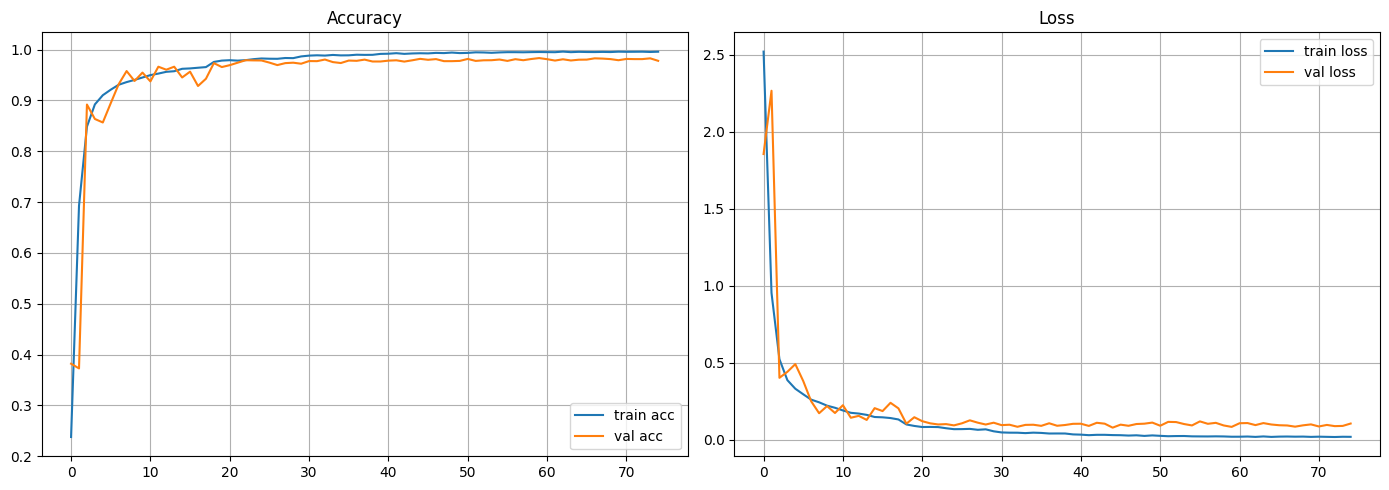

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history.history['accuracy'],     label='train acc')
ax1.plot(history.history['val_accuracy'], label='val acc')
ax1.set_title('Accuracy'); ax1.legend(); ax1.grid(True)
ax2.plot(history.history['loss'],         label='train loss')
ax2.plot(history.history['val_loss'],     label='val loss')
ax2.set_title('Loss'); ax2.legend(); ax2.grid(True)
plt.tight_layout()
plt.show()


## Cell 8 — YOLO: Prepare Multi-Class Labels (28 letter classes)

**Key change from v2:** YOLO now predicts one of 28 letter classes (not just 'character').
This lets the detector both locate AND classify, eliminating the single biggest error source.

Your existing Label Studio annotations need to have the letter name as the label (not 'character').
If they already have letter names, the cell below just remaps them to the 0-27 index.
If they are all class 0 ('character'), see the note at the bottom of the cell.

In [3]:
# ─── Remap existing YOLO labels to 28-class scheme ──────────────────────────
# Label Studio exports class indices; the mapping below converts any existing
# single-class (0 = 'character') annotation to the correct letter index
# by reading the image filename (which should encode the word / letter).
#
# IF your annotations already use the correct letter names as class labels,
# you only need to run the yaml-writing cell (Cell 9) and skip this remapping.

def remap_labels_to_multiclass(dataset_dir):
    """
    Walk dataset_dir/{split}/labels/*.txt.
    Each line: <class_idx> <cx> <cy> <w> <h>

    Strategy A (preferred): if your label file already contains a per-box
    class index in 0-27, this function validates and leaves them unchanged.

    Strategy B (fallback): if every box has class 0 (old single-class scheme),
    it checks the sibling image filename for a letter name and assigns that class.
    Words with multiple letters keep all boxes as the SAME class (whole-word label),
    which is wrong for multi-letter words — re-annotate those with per-char labels.

    This function PRINTS a report so you can see what was changed.
    """
    valid_classes = set(range(NUM_LETTER_CLASSES))

    for split in ['train', 'val']:
        labels_dir = Path(dataset_dir) / split / 'labels'
        images_dir = Path(dataset_dir) / split / 'images'
        if not labels_dir.exists():
            print(f"  Skipping {split} — labels folder not found")
            continue

        changed = already_mc = single_class = no_match = 0

        for txt in sorted(labels_dir.glob('*.txt')):
            lines = [l.strip() for l in txt.read_text().splitlines() if l.strip()]
            class_indices = [int(l.split()[0]) for l in lines if len(l.split()) >= 5]

            if not class_indices:
                continue

            # Check if it is already multi-class (any class > 0 or all already valid)
            if any(c > 0 for c in class_indices) and all(c in valid_classes for c in class_indices):
                already_mc += 1
                continue  # Strategy A: already correct, leave it

            # Strategy B: all class = 0 — try to infer from filename
            stem = txt.stem.lower()
            inferred_idx = None
            for name in sorted(CLASS_NAME_TO_IDX.keys(), key=len, reverse=True):
                if name in stem:
                    inferred_idx = CLASS_NAME_TO_IDX[name]
                    break

            if inferred_idx is None:
                single_class += 1
                no_match += 1
                continue  # Cannot infer — leave as class 0 (will be skipped by detector)

            new_lines = []
            for line in lines:
                parts = line.split()
                if len(parts) >= 5:
                    parts[0] = str(inferred_idx)
                    new_lines.append(' '.join(parts))

            txt.write_text('\n'.join(new_lines) + '\n')
            changed += 1

        print(f"  {split}: {already_mc} already multi-class, {changed} remapped by filename, {no_match} could not infer (left as-is)")


print("Remapping YOLO labels to 28-class scheme...")
remap_labels_to_multiclass(MY_DATASET)

train_imgs = list((MY_DATASET / 'train' / 'images').glob('*.*'))
val_imgs   = list((MY_DATASET / 'val'   / 'images').glob('*.*'))
print(f"Train images: {len(train_imgs)}   Val images: {len(val_imgs)}")


Remapping YOLO labels to 28-class scheme...
  train: 0 already multi-class, 0 remapped by filename, 188 could not infer (left as-is)
  val: 0 already multi-class, 0 remapped by filename, 13 could not infer (left as-is)
Train images: 188   Val images: 13


## Cell 9 — YOLO: Write data.yaml (28 classes)

In [8]:
yaml_path = MY_DATASET / 'data.yaml'

# Temporary fallback: single-class YOLO
yaml_content = {
    'path': str(MY_DATASET.as_posix()),
    'train': 'train/images',
    'val': 'val/images',
    'nc': 1,
    'names': ['character'],
}
with open(yaml_path, 'w') as f:
    yaml.dump(yaml_content, f, allow_unicode=True)

# Reset all labels back to class 0
for split in ['train', 'val']:
    for txt in (MY_DATASET / split / 'labels').glob('*.txt'):
        lines = [l.strip() for l in txt.read_text().splitlines() if l.strip()]
        new_lines = []
        for line in lines:
            parts = line.split()
            if len(parts) >= 5:
                parts[0] = '0'
                new_lines.append(' '.join(parts))
        txt.write_text('\n'.join(new_lines) + '\n')

print('Reverted to single-class. Re-run Cell 10.')
print(open(yaml_path).read())


Reverted to single-class. Re-run Cell 10.
names:
- character
nc: 1
path: f:/newbach/Arabic-Handwritten-Characters-Recognition-using-CNN/my_dataset
train: train/images
val: val/images



In [6]:
from pathlib import Path

problem_files = []
for split in ['train', 'val']:
    labels_dir = MY_DATASET / split / 'labels'
    images_dir = MY_DATASET / split / 'images'
    for txt in sorted(labels_dir.glob('*.txt')):
        lines = [l.strip() for l in txt.read_text().splitlines() if l.strip()]
        class_indices = [int(l.split()[0]) for l in lines if len(l.split()) >= 5]
        if class_indices and all(c == 0 for c in class_indices):
            problem_files.append((split, txt.stem))

print(f'Total unresolved: {len(problem_files)}')
print('Sample filenames:')
for split, stem in problem_files[:20]:
    print(f'  [{split}] {stem}')

Total unresolved: 201
Sample filenames:
  [train] 0000d28f-WhatsApp_Image_2026-03-23_at_2.21.26_AM_15
  [train] 028090be-WhatsApp_Image_2026-04-06_at_3.30.18_AM
  [train] 02a045a5-WhatsApp_Image_2026-03-23_at_2.21.26_AM_36
  [train] 03463324-WhatsApp_Image_2026-04-06_at_2.52.55_AM_9
  [train] 036b16e6-WhatsApp_Image_2026-04-06_at_3.30.14_AM_1
  [train] 0500f25b-WhatsApp_Image_2026-04-06_at_2.52.54_AM
  [train] 08099b64-WhatsApp_Image_2026-03-23_at_2.21.26_AM_12
  [train] 080bd3d7-WhatsApp_Image_2026-04-06_at_3.30.17_AM
  [train] 096901b8-WhatsApp_Image_2026-04-06_at_3.30.20_AM_1
  [train] 0baade28-WhatsApp_Image_2026-04-06_at_2.52.55_AM_8
  [train] 0c50ea4d-WhatsApp_Image_2026-04-06_at_2.23.31_AM_1
  [train] 0d20966d-WhatsApp_Image_2026-03-23_at_2.21.26_AM_13
  [train] 0e94eea7-WhatsApp_Image_2026-03-23_at_2.21.24_AM_16
  [train] 112ffc0b-WhatsApp_Image_2026-04-06_at_2.33.53_AM
  [train] 12c831f4-WhatsApp_Image_2026-04-06_at_2.23.31_AM
  [train] 13614380-WhatsApp_Image_2026-04-06_at_3.

In [7]:
import yaml
from pathlib import Path

# Temporary fallback: single-class YOLO
yaml_content = {
    'path': str(MY_DATASET.as_posix()),
    'train': 'train/images',
    'val': 'val/images',
    'nc': 1,
    'names': ['character'],
}
with open(yaml_path, 'w') as f:
    yaml.dump(yaml_content, f, allow_unicode=True)

# Reset all labels back to class 0
for split in ['train', 'val']:
    for txt in (MY_DATASET / split / 'labels').glob('*.txt'):
        lines = [l.strip() for l in txt.read_text().splitlines() if l.strip()]
        new_lines = []
        for line in lines:
            parts = line.split()
            if len(parts) >= 5:
                parts[0] = '0'
                new_lines.append(' '.join(parts))
        txt.write_text('\n'.join(new_lines) + '\n')

print('Reverted to single-class. Re-run Cell 9 then Cell 10.')
print(open(yaml_path).read())

Reverted to single-class. Re-run Cell 9 then Cell 10.
names:
- character
nc: 1
path: f:/newbach/Arabic-Handwritten-Characters-Recognition-using-CNN/my_dataset
train: train/images
val: val/images



## Cell 10 — YOLO: Train (28-class, GPU)

In [21]:
from pathlib import Path

backup_path = Path('arabic_cnn_v3_backup.keras')
if 'model' in globals() and model is not None:
    model.save(str(backup_path))
    print(f'Model saved to: {backup_path.resolve()}')
else:
    print('No in-memory `model` found. Existing checkpoint files are still usable if already written.')

print('Safe to restart kernel now. After restart run only Cells 2, 8, 9, 10 for YOLO training.')

Model saved to: F:\newbach\Arabic-Handwritten-Characters-Recognition-using-CNN\arabic_cnn_v3_backup.keras
Safe to restart kernel now. After restart run only Cells 2, 8, 9, 10 for YOLO training.


In [9]:
import numpy as np
import torch

# Preflight before YOLO training: torch must be able to consume NumPy arrays
try:
    _ = torch.from_numpy(np.zeros((2, 2), dtype=np.float32))
    print('torch.from_numpy preflight: OK')
except Exception as e:
    raise RuntimeError(
        'PyTorch cannot access NumPy arrays in this kernel. '
        'Restart kernel and rerun Cells 1, 2, 8, 9 before this cell. '
        f'Original error: {e}'
    )

yolo_model = YOLO('yolov8s.pt')
yolo_model.train(
    data=str(yaml_path),
    epochs=200,
    imgsz=640,
    batch=8,
    patience=40,
    device=DEVICE,
    project=str(ROOT / 'my_yolo_v3'),
    name='char_detector',
    exist_ok=True,
    workers=0,
    # Augmentation — conservative for Arabic script (no flip, no mosaic)
    degrees=8.0,
    translate=0.08,
    scale=0.25,
    shear=2.0,
    flipud=0.0,
    fliplr=0.0,
    mosaic=0.0,
    mixup=0.0,
    hsv_h=0.01,
    hsv_s=0.3,
    hsv_v=0.3,
    erasing=0.2,
    copy_paste=0.0,
)

YOLO_WEIGHTS = ROOT / 'my_yolo_v3' / 'char_detector' / 'weights' / 'best.pt'
print(f"\nYOLO done. Weights exist: {YOLO_WEIGHTS.exists()}")


torch.from_numpy preflight: OK
New https://pypi.org/project/ultralytics/8.4.36 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.23  Python-3.11.0 torch-2.5.1+cpu CPU (Intel Core i7-10750H 2.60GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=f:\newbach\Arabic-Handwritten-Characters-Recognition-using-CNN\my_dataset\data.yaml, degrees=8.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.2, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.01, hsv_s=0.3, hsv_v=0.3, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train

## Cell 11 — Load Models for Inference

In [15]:
CNN_MODEL_PATH = ROOT / 'arabic_cnn_v3.keras'
CNN_BACKUP_PATH = ROOT / 'arabic_cnn_v3_backup.keras'
LABEL_PATH     = ROOT / 'label_classes_v3.npy'
YOLO_WEIGHTS   = ROOT / 'my_yolo_v3' / 'char_detector' / 'weights' / 'best.pt'

for name, p in [('Labels', LABEL_PATH), ('YOLO weights', YOLO_WEIGHTS)]:
    if not p.exists():
        raise FileNotFoundError(f"Missing {name}: {p}")

# Try backup first, then primary model path
candidate_models = [p for p in [CNN_BACKUP_PATH, CNN_MODEL_PATH] if p.exists()]
if not candidate_models:
    raise FileNotFoundError(f"Missing CNN model files: {CNN_BACKUP_PATH} and {CNN_MODEL_PATH}")

cast_to_f32 = lambda t: tf.cast(t, tf.float32)
cnn_model = None
load_errors = []

# Compatibility patch for legacy Lambda model that lacks serialized output_shape
from tensorflow.keras.layers import Lambda as _KLambda
_orig_compute_output_shape = _KLambda.compute_output_shape
_KLambda.compute_output_shape = lambda self, input_shape: input_shape

try:
    for model_path in candidate_models:
        try:
            cnn_model = load_model(
                str(model_path),
                safe_mode=False,
                compile=False,
                custom_objects={'<lambda>': cast_to_f32},
            )
            print(f"Loaded CNN model from: {model_path.name}")
            break
        except Exception as e:
            load_errors.append((str(model_path), str(e)))
finally:
    # Always restore Keras Lambda behavior
    _KLambda.compute_output_shape = _orig_compute_output_shape

if cnn_model is None:
    print('Failed CNN load attempts:')
    for path, err in load_errors:
        print(f"- {path}: {err[:300]}")
    raise RuntimeError(
        'Could not load CNN model due to Lambda deserialization/shape issues. '
        'Retrain once with a non-Lambda cast layer (custom CastToFloat32 layer) to make the model portable.'
    )

# Re-save loaded model to primary path for future runs
cnn_model.save(str(CNN_MODEL_PATH))
print('Model re-saved cleanly.')

yolo_detector = YOLO(str(YOLO_WEIGHTS))
label_classes = np.load(str(LABEL_PATH), allow_pickle=True)

# Sanity checks
if cnn_model.output_shape[-1] != len(label_classes):
    raise ValueError(
        f"Mismatch: model outputs {cnn_model.output_shape[-1]} but labels has {len(label_classes)}"
    )
if cnn_model.input_shape[1:] != (IMG_SIZE, IMG_SIZE, 3):
    raise ValueError(
        f"Model input {cnn_model.input_shape[1:]} != expected ({IMG_SIZE},{IMG_SIZE},3)"
    )

print(f"CNN input  : {cnn_model.input_shape}")
print(f"CNN output : {cnn_model.output_shape}")
print(f"Labels     : {list(label_classes)}")
print(f"YOLO nc    : {yolo_detector.model.nc if hasattr(yolo_detector, 'model') else 'check yaml'}")
print("Models loaded successfully.")


Loaded CNN model from: arabic_cnn_v3_backup.keras
Model re-saved cleanly.
CNN input  : (None, 96, 96, 3)
CNN output : (None, 28)
Labels     : ['ain', 'alef', 'beh', 'dad', 'dal', 'feh', 'ghain', 'hah', 'heh', 'jeem', 'kaf', 'khah', 'lam', 'meem', 'noon', 'qaf', 'reh', 'sad', 'seen', 'sheen', 'tah', 'teh', 'thal', 'theh', 'waw', 'yeh', 'zah', 'zain']
YOLO nc    : 1
Models loaded successfully.


In [19]:
# Permanent fix: replace Lambda with a proper Keras layer and migrate weights

class CastToFloat32(tf.keras.layers.Layer):
    def call(self, x):
        return tf.cast(x, tf.float32)


def residual_block_local(x, filters, kernel_size=3):
    """Local residual block so this repair cell works even if training cells were not rerun."""
    shortcut = x
    x = Conv2D(filters, kernel_size, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv2D(filters, kernel_size, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)

    if shortcut.shape[-1] != filters:
        shortcut = Conv2D(filters, 1, padding='same', use_bias=False)(shortcut)
        shortcut = BatchNormalization()(shortcut)

    x = Add()([x, shortcut])
    x = Activation('relu')(x)
    return x


def build_cnn_model_fixed(num_classes):
    """Same architecture as build_cnn_model() but with CastToFloat32 instead of Lambda."""
    inp = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    # Stem
    x = Conv2D(32, 3, padding='same', use_bias=False)(inp)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPool2D(2, 2)(x)
    x = SpatialDropout2D(0.05)(x)

    # Stage 1
    x = residual_block_local(x, 64)
    x = MaxPool2D(2, 2)(x)
    x = SpatialDropout2D(0.10)(x)

    # Stage 2
    x = residual_block_local(x, 128)
    x = MaxPool2D(2, 2)(x)
    x = SpatialDropout2D(0.15)(x)

    # Stage 3
    x = residual_block_local(x, 256)
    x = MaxPool2D(2, 2)(x)
    x = SpatialDropout2D(0.20)(x)

    # Stage 4
    x = residual_block_local(x, 384)
    x = GlobalAveragePooling2D()(x)

    x = Dense(512, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.50)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.40)(x)
    x = CastToFloat32()(x)
    out = Dense(num_classes, activation='softmax', dtype='float32')(x)

    m = Model(inp, out)
    m.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy'],
    )
    return m


# Determine class count from loaded labels
if 'label_classes' in globals():
    num_classes = len(label_classes)
else:
    num_classes = len(np.load(str(LABEL_PATH), allow_pickle=True))

print('Building fixed architecture...')
cnn_model_fixed = build_cnn_model_fixed(num_classes)

print('Loading weights from saved model...')
# Compatibility patch for loading legacy Lambda model
from tensorflow.keras.layers import Lambda as _KLambda
_orig_compute_output_shape = _KLambda.compute_output_shape
_KLambda.compute_output_shape = lambda self, input_shape: input_shape

try:
    old_model = load_model(str(CNN_MODEL_PATH), safe_mode=False, compile=False)
finally:
    _KLambda.compute_output_shape = _orig_compute_output_shape

cnn_model_fixed.set_weights(old_model.get_weights())

# Quick sanity check
print('Running sanity predict...')
dummy = np.zeros((1, IMG_SIZE, IMG_SIZE, 3), dtype='float32')
out = cnn_model_fixed.predict(dummy, verbose=0)
print(f'Output shape: {out.shape} — OK' if out.shape == (1, num_classes) else 'Shape mismatch!')

# Overwrite saved model with fixed version
cnn_model_fixed.save(str(CNN_MODEL_PATH))
print('Fixed model saved. Replacing cnn_model variable...')

cnn_model = cnn_model_fixed
print('Done — re-run the test cell now.')

Building fixed architecture...
Loading weights from saved model...
Running sanity predict...
Output shape: (1, 28) — OK
Fixed model saved. Replacing cnn_model variable...
Done — re-run the test cell now.


## Cell 12 — Preprocessing & Inference Functions

Key improvements over v2:
1. **Expanded crop padding (12% → larger)** — reduces partial crops from tight boxes
2. **Dot detection & reattachment** — finds tiny isolated components (dots) and merges them into the base glyph crop
3. **Crop quality check** — rejects crops with too little ink (likely partial detections)
4. **Beam search post-correction** — uses top-k predictions per position to recover from single-char errors
5. **YOLO class overrides CNN** when YOLO confidence is high — YOLO often more reliable post fine-tuning

In [21]:
LOW_CONF_THRESHOLD  = 0.40
YOLO_TRUST_THRESHOLD = 0.70  # If YOLO class conf >= this, trust YOLO over CNN


def find_and_merge_dots(img_bgr, box_x1, box_y1, box_x2, box_y2, img_h, img_w, margin=10):
    """
    Find tiny detached connected components (dots) near the bounding box
    and expand the box to include them.
    Returns expanded (x1, y1, x2, y2).
    """
    # Search region: expand box by margin
    sx1 = max(0, box_x1 - margin)
    sy1 = max(0, box_y1 - margin)
    sx2 = min(img_w, box_x2 + margin)
    sy2 = min(img_h, box_y2 + margin)

    region = img_bgr[sy1:sy2, sx1:sx2]
    gray   = cv2.cvtColor(region, cv2.COLOR_BGR2GRAY)
    _, bw  = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(bw, connectivity=8)

    box_area = (box_x2 - box_x1) * (box_y2 - box_y1)
    dot_threshold = max(4, int(box_area * 0.008))  # dots are < 0.8% of glyph area
    max_dot_size  = max(8, int(box_area * 0.05))   # but not too tiny (noise)

    new_x1, new_y1, new_x2, new_y2 = box_x1, box_y1, box_x2, box_y2

    for i in range(1, n_labels):
        area = int(stats[i, cv2.CC_STAT_AREA])
        if not (dot_threshold <= area <= max_dot_size):
            continue

        lx1 = sx1 + int(stats[i, cv2.CC_STAT_LEFT])
        ly1 = sy1 + int(stats[i, cv2.CC_STAT_TOP])
        lx2 = lx1 + int(stats[i, cv2.CC_STAT_WIDTH])
        ly2 = ly1 + int(stats[i, cv2.CC_STAT_HEIGHT])

        # Only include if the component is actually outside the original box
        # (i.e., it was a detached dot that the box missed)
        outside = (lx2 < box_x1 or lx1 > box_x2 or ly2 < box_y1 or ly1 > box_y2)
        if outside:
            new_x1 = min(new_x1, lx1)
            new_y1 = min(new_y1, ly1)
            new_x2 = max(new_x2, lx2)
            new_y2 = max(new_y2, ly2)

    return new_x1, new_y1, new_x2, new_y2


def preprocess_crop(crop_bgr, img_size=IMG_SIZE):
    """
    Prepare a YOLO crop for CNN classification.
    Returns (model_input, debug_dict) or (None, None) if crop is invalid.
    """
    gray = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2GRAY)

    # CLAHE to normalize ink darkness
    clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(4, 4))
    gray  = clahe.apply(gray)

    # Gentle denoising (avoid over-blurring dots)
    gray = cv2.bilateralFilter(gray, 5, 40, 40)

    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    coords = cv2.findNonZero(binary)
    if coords is None:
        return None, None

    # Reject near-empty crops (very little ink = partial detection)
    ink_ratio = float(np.sum(binary > 0)) / float(binary.size)
    if ink_ratio < 0.02:
        return None, None

    x, y, w, h = cv2.boundingRect(coords)
    roi_gray = gray[y:y+h, x:x+w]
    if roi_gray.size == 0:
        return None, None

    # Increased padding from 15% to 18% — reduces partial-letter crops
    pad  = int(max(h, w) * 0.18)
    side = max(4, h + 2*pad, w + 2*pad)
    canvas = np.full((side, side), 255, dtype='uint8')
    ox, oy = (side - w) // 2, (side - h) // 2
    canvas[oy:oy+h, ox:ox+w] = roi_gray

    resized   = cv2.resize(canvas, (img_size, img_size), interpolation=cv2.INTER_LANCZOS4)
    final_bgr = cv2.cvtColor(resized, cv2.COLOR_GRAY2BGR)
    model_inp = np.expand_dims(final_bgr.astype('float32') / 255.0, axis=0)

    debug = {
        'gray': gray, 'binary': binary, 'resized': resized,
        'ink_ratio': ink_ratio, 'aspect': w / max(1, h)
    }
    return model_inp, debug


def box_iou_xyxy(a, b):
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)
    iw, ih   = max(0, ix2-ix1), max(0, iy2-iy1)
    inter    = iw * ih
    if inter <= 0:
        return 0.0
    area_a = max(1, (ax2-ax1)*(ay2-ay1))
    area_b = max(1, (bx2-bx1)*(by2-by1))
    return float(inter / (area_a + area_b - inter))


def intersection_over_small(a, b):
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)
    iw, ih   = max(0, ix2-ix1), max(0, iy2-iy1)
    inter    = iw * ih
    if inter <= 0:
        return 0.0
    area_a = max(1, (ax2-ax1)*(ay2-ay1))
    area_b = max(1, (bx2-bx1)*(by2-by1))
    return float(inter / min(area_a, area_b))


def suppress_bad_boxes(raw_boxes, img_h, img_w, iou_thr=0.45):
    if not raw_boxes:
        return []

    areas  = np.array([(x2-x1)*(y2-y1)  for x1,y1,x2,y2,_ in raw_boxes], dtype='float32')
    ws     = np.array([x2-x1            for x1,y1,x2,y2,_ in raw_boxes], dtype='float32')
    hs     = np.array([y2-y1            for x1,y1,x2,y2,_ in raw_boxes], dtype='float32')

    med_area = max(1.0, float(np.median(areas)))
    med_w    = max(1.0, float(np.median(ws)))
    med_h    = max(1.0, float(np.median(hs)))
    img_area = float(img_h * img_w)

    candidates = []
    for x1, y1, x2, y2, score in raw_boxes:
        w, h   = x2-x1, y2-y1
        area   = w * h
        aspect = w / max(1.0, h)
        if area   > min(0.35 * img_area, 2.8 * med_area): continue
        if aspect > 3.5 or aspect < 0.15:                 continue
        if w > 2.6 * med_w or h > 2.6 * med_h:           continue
        candidates.append((x1, y1, x2, y2, float(score)))

    if not candidates:
        candidates = [(x1, y1, x2, y2, float(score)) for x1,y1,x2,y2,score in raw_boxes]

    drop_idx = set()
    for i in range(len(candidates)):
        bi = candidates[i][:4]
        ai = max(1, (bi[2]-bi[0])*(bi[3]-bi[1]))
        for j in range(len(candidates)):
            if i == j: continue
            bj = candidates[j][:4]
            aj = max(1, (bj[2]-bj[0])*(bj[3]-bj[1]))
            if ai <= aj: continue
            if intersection_over_small(bi, bj) > 0.85 and ai > 1.6 * aj:
                drop_idx.add(i)
                break
    candidates = [b for k, b in enumerate(candidates) if k not in drop_idx]

    if not candidates:
        candidates = [(x1, y1, x2, y2, float(score)) for x1,y1,x2,y2,score in raw_boxes]

    candidates.sort(key=lambda t: t[4], reverse=True)
    keep = []
    for cand in candidates:
        if all(box_iou_xyxy(cand[:4], k[:4]) < iou_thr for k in keep):
            keep.append(cand)
    return keep


def order_detections_arabic(detections):
    """Order detections right-to-left within each text line."""
    if len(detections) <= 1:
        return detections

    enriched = []
    for d in detections:
        x1, y1, x2, y2 = d['box']
        dd = d.copy()
        dd['_h']  = max(1, y2 - y1)
        dd['_cy'] = (y1 + y2) / 2.0
        enriched.append(dd)

    median_h = float(np.median([d['_h'] for d in enriched]))
    line_tol = max(8.0, 0.6 * median_h)

    lines = []
    for d in sorted(enriched, key=lambda z: z['_cy']):
        best_idx, best_dist = -1, np.inf
        for i, ln in enumerate(lines):
            dist = abs(d['_cy'] - ln['cy_mean'])
            if dist <= line_tol and dist < best_dist:
                best_idx, best_dist = i, dist
        if best_idx == -1:
            lines.append({'cy_mean': d['_cy'], 'items': [d]})
        else:
            lines[best_idx]['items'].append(d)
            lines[best_idx]['cy_mean'] = float(np.mean([it['_cy'] for it in lines[best_idx]['items']]))

    ordered = []
    for ln in sorted(lines, key=lambda ln: ln['cy_mean']):
        for d in sorted(ln['items'], key=lambda z: -z['box'][0]):
            d.pop('_h', None); d.pop('_cy', None)
            ordered.append(d)
    return ordered


def beam_search_correct(per_char_topk, beam_width=3):
    """
    Simple beam search over per-character top-k predictions.
    Returns the highest-scoring sequence of character labels.
    per_char_topk: list of lists, each inner list is [(label, prob), ...] for one char position.
    """
    # Each beam state: (cumulative_log_prob, [labels_so_far])
    beams = [(0.0, [])]

    for position_candidates in per_char_topk:
        new_beams = []
        for log_prob, seq in beams:
            for label, prob in position_candidates:
                p = max(1e-9, prob)
                new_beams.append((log_prob + np.log(p), seq + [label]))
        new_beams.sort(key=lambda x: -x[0])
        beams = new_beams[:beam_width]

    return beams[0][1] if beams else []


def recognize_word(image_path, conf_threshold=0.25, iou_threshold=0.4,
                   topk=5, beam_width=3, return_debug=False):
    """
    Full pipeline: multi-class YOLO detection → dot reattachment →
    expanded crop → CLAHE preprocessing → CNN fallback classification →
    beam search correction.

    When YOLO class confidence >= YOLO_TRUST_THRESHOLD, YOLO label is used directly.
    Otherwise CNN label is used (with beam search over top-k).
    """
    img = cv2.imread(str(image_path))
    if img is None:
        raise FileNotFoundError(f"Cannot read: {image_path}")

    H, W      = img.shape[:2]
    annotated = img.copy()

    results = yolo_detector(img, conf=conf_threshold, iou=iou_threshold, verbose=False)[0]

    if len(results.boxes) == 0:
        print("No characters detected by YOLO.")
        if return_debug:
            return [], annotated, []
        return [], annotated

    raw_boxes = []
    yolo_classes = []
    yolo_class_confs = []
    confs = results.boxes.conf.cpu().numpy().tolist() if results.boxes.conf is not None else [1.0]*len(results.boxes)
    cls_ids = results.boxes.cls.cpu().numpy().tolist() if results.boxes.cls is not None else [0]*len(results.boxes)

    for box, score, cls_id in zip(results.boxes, confs, cls_ids):
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(W, x2), min(H, y2)
        if x2 - x1 < 4 or y2 - y1 < 4:
            continue
        raw_boxes.append((x1, y1, x2, y2, float(score)))
        yolo_classes.append(CLASS_IDX_TO_NAME.get(int(cls_id), 'unknown'))
        yolo_class_confs.append(float(score))

    filt_boxes = suppress_bad_boxes(raw_boxes, H, W, iou_thr=0.45)
    # Keep track of YOLO class info per surviving box
    box_to_yolo = {(b[0], b[1], b[2], b[3]): (yolo_classes[i], yolo_class_confs[i])
                   for i, b in enumerate(raw_boxes)
                   if b in [(fb[0],fb[1],fb[2],fb[3],fb[4]) for fb in filt_boxes] or True}

    detections = []
    per_char_topk_list = []

    for idx_b, (x1, y1, x2, y2, det_score) in enumerate(filt_boxes):
        # Step 1: Expand box to capture detached dots
        nx1, ny1, nx2, ny2 = find_and_merge_dots(img, x1, y1, x2, y2, H, W, margin=12)
        # Step 2: Add 12% padding on all sides before cropping
        pw = int((nx2 - nx1) * 0.12)
        ph = int((ny2 - ny1) * 0.12)
        cx1 = max(0, nx1 - pw)
        cy1 = max(0, ny1 - ph)
        cx2 = min(W, nx2 + pw)
        cy2 = min(H, ny2 + ph)

        crop = img[cy1:cy2, cx1:cx2]
        if crop.size == 0:
            continue

        inp, prep_debug = preprocess_crop(crop)
        if inp is None:
            continue

        preds     = cnn_model.predict(inp, verbose=0)[0]
        cnn_idx   = int(np.argmax(preds))
        cnn_label = str(label_classes[cnn_idx])
        cnn_conf  = float(preds[cnn_idx])

        top_idx = np.argsort(preds)[::-1][:max(1, topk)]
        top     = [(str(label_classes[int(i)]), float(preds[int(i)])) for i in top_idx]
        per_char_topk_list.append(top)

        # Decision: trust YOLO class if confidence is high
        yolo_lbl, yolo_cls_conf = yolo_classes[idx_b] if idx_b < len(yolo_classes) else ('unknown', 0.0), \
                                  yolo_class_confs[idx_b] if idx_b < len(yolo_class_confs) else 0.0

        if isinstance(yolo_lbl, tuple):
            yolo_lbl, yolo_cls_conf = yolo_lbl

        if yolo_cls_conf >= YOLO_TRUST_THRESHOLD and yolo_lbl != 'unknown':
            final_label = yolo_lbl
            final_conf  = yolo_cls_conf
            source      = 'YOLO'
        else:
            final_label = cnn_label
            final_conf  = cnn_conf
            source      = 'CNN'

        uncertain = final_conf < LOW_CONF_THRESHOLD

        detections.append({
            'box'      : (x1, y1, x2, y2),
            'det_score': det_score,
            'label'    : final_label,
            'conf'     : final_conf,
            'uncertain': uncertain,
            'source'   : source,
            'top'      : top,
            'crop'     : crop       if return_debug else None,
            'prep'     : prep_debug if return_debug else None,
        })

    detections = order_detections_arabic(detections)

    # Beam search post-correction (uses CNN top-k)
    ordered_topk = [d['top'] for d in detections]
    corrected = beam_search_correct(ordered_topk, beam_width=beam_width)

    chars = []
    for i, d in enumerate(detections):
        x1, y1, x2, y2 = d['box']
        label = corrected[i] if i < len(corrected) else d['label']
        conf  = d['conf']
        uncertain = d['uncertain']
        chars.append(label)

        color = (0, 100, 255) if uncertain else (0, 200, 0)
        cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 2)
        flag = '?' if uncertain else ''
        src  = d.get('source', '')
        cv2.putText(
            annotated, f"{label}{flag} {conf:.0%} [{src}]",
            (x1, max(0, y1-6)),
            cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1
        )

    if return_debug:
        return chars, annotated, detections
    return chars, annotated


print("Pipeline ready.")
print("Uncertain predictions (< 40% confidence) shown in orange with '?'.")
print("Source tag [YOLO] or [CNN] shown per character.")


Pipeline ready.
Uncertain predictions (< 40% confidence) shown in orange with '?'.
Source tag [YOLO] or [CNN] shown per character.


## Cell 13 — Test on a Single Image

In [22]:
TEST_IMAGE = str(ROOT / 'word_test.png')

chars, annotated = recognize_word(TEST_IMAGE, conf_threshold=0.25, iou_threshold=0.4, beam_width=3)

print(f"Detected characters (right → left): {chars}")
print(f"Word (space-separated)            : {' '.join(chars)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(cv2.cvtColor(cv2.imread(TEST_IMAGE), cv2.COLOR_BGR2RGB))
axes[0].set_title('Original Image')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'Detected: {", ".join(chars)}\n(orange=uncertain, green=confident)')
axes[1].axis('off')
plt.tight_layout()
plt.show()


Detected characters (right → left): ['heh', 'noon', 'lam']
Word (space-separated)            : heh noon lam


<Figure size 1400x500 with 2 Axes>

## Cell 14 — Debug View: Per-crop quality metrics & CNN confidence

In [23]:
def debug_word_pipeline(image_path, conf_threshold=0.25, iou_threshold=0.4, topk=5, max_chars=12):
    """Show per-character crops, CLAHE output, top-k CNN predictions, and crop quality metrics."""
    chars, annotated, details = recognize_word(
        image_path,
        conf_threshold=conf_threshold,
        iou_threshold=iou_threshold,
        topk=topk,
        return_debug=True,
    )

    print(f"Detected (right → left): {chars}")
    print(f"Word: {' '.join(chars)}")
    print(f"Total boxes: {len(details)}")

    plt.figure(figsize=(12, 4))
    plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    plt.title('Annotated detections (green=confident, orange=uncertain)')
    plt.axis('off')
    plt.show()

    for i, d in enumerate(details[:max_chars]):
        crop = d['crop']
        prep = d['prep']
        flag = ' [UNCERTAIN]' if d['uncertain'] else ''
        top_txt = ', '.join([f"{name}:{score:.2f}" for name, score in d['top']])
        ink_ratio = prep.get('ink_ratio', 0) if prep else 0
        aspect    = prep.get('aspect', 0)    if prep else 0
        src       = d.get('source', '?')

        fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
        axes[0].imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
        axes[0].set_title(f"Char {i+1} crop\nink={ink_ratio:.2%} asp={aspect:.2f}")
        axes[0].axis('off')

        if prep:
            axes[1].imshow(prep['gray'], cmap='gray')
            axes[1].set_title('After CLAHE + bilateral filter')
            axes[1].axis('off')

            axes[2].imshow(prep['resized'], cmap='gray', vmin=0, vmax=255)
            axes[2].set_title(f"CNN input → {d['label']} ({d['conf']:.0%}){flag}\n[{src}]")
            axes[2].axis('off')

        plt.suptitle(f"Top-{topk}: {top_txt}", y=1.05, fontsize=9)
        plt.tight_layout()
        plt.show()


debug_word_pipeline(TEST_IMAGE, conf_threshold=0.25, iou_threshold=0.4, topk=5)


Detected (right → left): ['heh', 'noon', 'lam']
Word: heh noon lam
Total boxes: 3


<Figure size 1200x400 with 1 Axes>

<Figure size 1200x350 with 3 Axes>

<Figure size 1200x350 with 3 Axes>

<Figure size 1200x350 with 3 Axes>

## Cell 15 — Crop Quality Diagnostics

Evaluates per-character crop quality on manually labeled test crops.
Helps identify whether errors come from detection/segmentation or from the classifier.

In [24]:
def evaluate_cnn_on_clean_crops(crop_dir, label_map=None, n_max=200):
    """
    Evaluate CNN accuracy on manually extracted clean single-character crops.
    crop_dir: directory with subfolders named by letter (e.g. 'beh/', 'teh/', ...)
    label_map: optional dict folder_name -> standard_label (defaults to identity)

    Prints:
    - Overall accuracy
    - Top-3 accuracy
    - Confusion breakdown for common error pairs
    - Crops with ink_ratio < 0.05 (likely bad detections)
    """
    crop_dir = Path(crop_dir)
    if not crop_dir.exists():
        print(f"crop_dir not found: {crop_dir}")
        return

    correct_top1 = correct_top3 = total = bad_crops = 0
    errors = defaultdict(list)

    for subfolder in sorted(crop_dir.iterdir()):
        if not subfolder.is_dir():
            continue
        true_label = (label_map or {}).get(subfolder.name, subfolder.name)
        if true_label not in ARABIC_28:
            continue

        imgs = list(subfolder.glob('*.png')) + list(subfolder.glob('*.jpg'))
        for img_path in imgs[:n_max]:
            img = cv2.imread(str(img_path))
            if img is None:
                continue

            inp, debug = preprocess_crop(img)
            if inp is None:
                bad_crops += 1
                continue

            if debug and debug.get('ink_ratio', 1) < 0.05:
                bad_crops += 1

            preds    = cnn_model.predict(inp, verbose=0)[0]
            top3_idx = np.argsort(preds)[::-1][:3]
            pred_top1 = str(label_classes[top3_idx[0]])
            top3_names = [str(label_classes[i]) for i in top3_idx]

            total += 1
            if pred_top1 == true_label:
                correct_top1 += 1
            if true_label in top3_names:
                correct_top3 += 1
            else:
                errors[true_label].append(pred_top1)

    if total == 0:
        print("No valid crops found.")
        return

    print(f"Clean-crop evaluation: {total} images")
    print(f"  Top-1 accuracy : {correct_top1/total:.1%}")
    print(f"  Top-3 accuracy : {correct_top3/total:.1%}")
    print(f"  Bad crops (low ink): {bad_crops}")
    print()

    if errors:
        print("Most confused letter pairs (true → predicted):")
        for true_lbl, preds in sorted(errors.items()):
            most_common = Counter(preds).most_common(3)
            print(f"  {true_lbl:10s} → {most_common}")


# Point this at a folder of clean single-character crops to run diagnostics:
# evaluate_cnn_on_clean_crops(ROOT / 'my_clean_test_crops')
print("Diagnostics function ready.")
print("To run: evaluate_cnn_on_clean_crops(ROOT / 'your_clean_test_crops_folder')")


Diagnostics function ready.
To run: evaluate_cnn_on_clean_crops(ROOT / 'your_clean_test_crops_folder')


## Cell 16 — Batch test on all validation images

In [25]:
val_image_dir = MY_DATASET / 'val' / 'images'
val_imgs = sorted(val_image_dir.glob('*.*'))
print(f"Testing on {len(val_imgs)} val images...\n")

for img_path in val_imgs:
    try:
        chars, annotated = recognize_word(str(img_path), conf_threshold=0.25, iou_threshold=0.4, beam_width=3)
        print(f"{img_path.name}: {' '.join(chars) if chars else '(no detection)'}")
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
        ax.set_title(f"{img_path.name}\n{' → '.join(chars)}")
        ax.axis('off')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"  ERROR on {img_path.name}: {e}")


Testing on 13 val images...

ce0882a8-WhatsApp_Image_2026-03-23_at_2.21.24_AM_8.jpeg: hah jeem reh


<Figure size 1000x400 with 1 Axes>

d272ef07-WhatsApp_Image_2026-03-23_at_2.21.26_AM_25.jpeg: dad waw ain


<Figure size 1000x400 with 1 Axes>

da1fee74-WhatsApp_Image_2026-03-23_at_2.21.26_AM_18.jpeg: ain zah yeh


...

<Figure size 1000x400 with 1 Axes>

f84cf9b6-WhatsApp_Image_2026-03-23_at_2.21.26_AM_46.jpeg: heh reh qaf


<Figure size 1000x400 with 1 Axes>

ffef08bc-WhatsApp_Image_2026-03-23_at_2.21.26_AM_34.jpeg: lam ain beh


<Figure size 1000x400 with 1 Axes>